Given an Hamiltonian $H$  and a trial state $\psi_T$ with non zero overlap $\gamma$ with the exact ground state.
If we define the simple filtering operator $\prod_i \cos(Ht_i+\delta_i)$, that can be implemented with the circuit described in the paper we have
 \begin{eqnarray}
 \ket{\Psi_T}\longrightarrow\ket{\phi}&=&\frac{1}{{\cal N}}\prod_i\cos(t_iH+\delta_i)\ket{\psi_T}=\frac{1}{\mathcal{N}}\sum_n \bra{\Psi_T}n\rangle \prod_i\cos(E_nt_i+\delta_i)\ket{n}
 \end{eqnarray} 
 where $\mathcal{N}$ is the following normalization factor
 \begin{eqnarray}
 {\cal N}^2&=&\bra{\Psi_T}\prod_i \cos^2(Ht_i+\delta_i)\ket{\Psi_T}=\sum_n \lvert\bra{\Psi_T}n\rangle\rvert^2 \prod_i\cos^2(t_iE_n+\delta_i)\\
 \end{eqnarray}
 in order to simplify things we define a trial state having overlap $\gamma$ with the ground state as follows
 \begin{eqnarray}
 \ket{\psi_T}&=&\gamma\ket{0}+\sum_{n>1}\frac{\sqrt{1-\gamma^2}}{\sqrt{N-1}}\ket{n}\qquad \bra{\psi_T}\psi_T\rangle=1
 \end{eqnarray}
 which leads to
 \begin{eqnarray}
 {\cal N}^2&=&\gamma^2\prod_i\cos^2(t_iE_0+\delta_i)+\sum_{n>1}^N\frac{1-\gamma^2}{N-1}\prod_i\cos^2(t_iE_n+\delta_i)\\
 &=&\gamma^2\prod_i\cos^2(t_iE_0+\delta_i)+\frac{1-\gamma^2}{N-1}\sum_{n>1}^N\prod_i\cos^2(t_iE_n+\delta_i)
 \end{eqnarray}
  We want to minimize the following cost function
 \begin{eqnarray}
 C=\lvert \ket{\phi}-\ket{\Psi_{GS}}\rvert^2=2-2Re\bra{\phi}\Psi_{GS}\rangle
 \end{eqnarray}
 where
 \begin{eqnarray}
 \bra{\Psi_{GS}}\phi\rangle&=&\frac{1}{{\cal{N} }}\bra{\Psi_T}0\rangle \prod_i \cos(E_0t_i+\delta_i)=\frac{1}{{\cal N}}\gamma \prod_i\cos(E_0t_i+\delta_i)
 \end{eqnarray}
and explicitly the cost function is
\begin{eqnarray}
C=2\left[1-\gamma\frac{\prod_i\cos(E_0t_i+\delta_i)}{{\cal N}}\right]
\end{eqnarray}

for the very pessimistic case in which the trial state is uniform the expression of ${\cal N}$ takes the simplified form:
\begin{eqnarray}
{\cal N}&=&\frac{1}{N}\sum_n  \prod_i\cos^2(t_iE_n+\delta_i) \qquad \gamma=\frac{1}{N}
\end{eqnarray}
which leads to the cost function
\begin{eqnarray}
C=2\left[1-\frac{\prod_i\cos(E_0t_i+\delta_i)}{\prod_i\cos^2(t_iE_n+\delta_i)}\right]
\end{eqnarray}
that does not have explicit dependence from the overlap.

In [2]:
import numpy as np
from scipy import optimize as opt
import matplotlib.pyplot as plt
from typing import List, Dict, Optional, Tuple

# ----------------------------------------------------------------------
# Helper functions (unchanged)
# ----------------------------------------------------------------------
def fixtimes(times, totaltime):
    xf = totaltime / np.sum(np.abs(times))
    times[:] = xf * times
    return times

def unpack(timesphases):
    ndouble = len(timesphases)
    n = ndouble // 2
    return timesphases[:n].copy(), timesphases[n:].copy()

def timesconstraints(timesphases, total_time):
    times, _ = unpack(timesphases)
    return abs(np.sum(times) - total_time)

def probability_constraints(timesphases, energies, overlap):
    _, phases = unpack(timesphases)
    return np.prod(np.cos(phases)**2) - 0.9

def probability_constraintsb(timesphases, energies, overlap, pos):
    times, phases = unpack(timesphases)
    return np.prod((np.cos(energies[pos] * times + phases))**2) - 0.9

def new_func_v3(timesphases, energies, overlap):
    ndouble = len(timesphases)
    n = ndouble // 2
    times = timesphases[:n]
    phases = timesphases[n:]
    num = np.prod(np.cos(phases))
    cos_vals = np.cos(energies[:, None] * times + phases)
    den = np.prod(cos_vals**2, axis=1).sum()
    return abs(1 - num / np.sqrt(den))

def new_func_v4(timesphases, energies, overlap):
    ndouble = len(timesphases)
    n = ndouble // 2
    times = timesphases[:n]
    phases = timesphases[n:]
    num = 1.0
    cos_vals = np.cos(energies[:, None] * times)
    den = np.prod(cos_vals**2, axis=1).sum()
    return abs(1 - num / np.sqrt(den))

# ----------------------------------------------------------------------
# FilterBuilder with evaluation & plotting
# ----------------------------------------------------------------------
class FilterBuilder:
    _METHODS = {
        "v3":  (new_func_v3,  probability_constraints,  False),
        "v3b": (new_func_v3,  probability_constraintsb, True),
        "v4":  (new_func_v4,  None,                     False),
    }

    def __init__(
        self,
        total_time,
        energies,
        overlap,
        a=4,
        b=15,
        optimizer="SLSQP",
        maxiter=5000,
        ftol=1e-12,
    ):
        self.total_time = float(total_time)
        self.energies = np.asarray(energies, dtype=float)
        self.overlap = float(overlap)
        self.a = int(a)
        self.b = int(b)
        self.optimizer = optimizer
        self.opts = {"maxiter": maxiter, "ftol": ftol}

    # ------------------------------------------------------------------
    def build(self, method="v4") -> List[Dict]:
        if method not in self._METHODS:
            raise ValueError(f"method must be one of {list(self._METHODS)}")

        objective, extra_constr, needs_pos = self._METHODS[method]
        results = []

        for ntimes in range(self.a, self.b + 1):
            # initial guess
            times = np.ones(ntimes)
            for i in range(1, ntimes):
                times[i] = times[i - 1] / 2.0
            times = fixtimes(times, self.total_time)

            timesphases = np.zeros(2 * ntimes)
            timesphases[:ntimes] = times

            # bounds
            bnd_times = [(0.0, self.total_time / 3.0)] * ntimes
            bnd_phases = [(-np.pi / 2, np.pi / 2)] * ntimes
            bnds = bnd_times + bnd_phases

            # constraints
            constraints = [
                {"type": "eq", "fun": timesconstraints, "args": (self.total_time,)}
            ]
            if extra_constr is not None:
                if needs_pos:
                    constraints.append(
                        {"type": "ineq", "fun": extra_constr,
                         "args": (self.energies, self.overlap, 0)}
                    )
                else:
                    constraints.append(
                        {"type": "ineq", "fun": extra_constr,
                         "args": (self.energies, self.overlap)}
                    )

            # optimize
            res = opt.minimize(
                objective,
                x0=timesphases,
                args=(self.energies, self.overlap),
                method=self.optimizer,
                bounds=bnds,
                constraints=constraints,
                options=self.opts,
                tol=1e-13,
            )

            times_opt = res.x[:ntimes]
            phases_opt = res.x[ntimes:]

            results.append({
                "ntimes": ntimes,
                "times": times_opt.copy(),
                "phases": phases_opt.copy(),
                "fun": float(res.fun),
                "success": bool(res.success),
                "message": str(res.message),
                "result": res  # full scipy result
            })

            print(f"ntimes={ntimes:2d}  time={times_opt.sum():.6f}  fun={res.fun:.3e}  success={res.success}")

        return results

    # ------------------------------------------------------------------
    @staticmethod
    def apply_filter(times: np.ndarray, phases: np.ndarray, energies: np.ndarray, state: np.ndarray) -> Tuple[float, np.ndarray]:
        """
        Apply pulse sequence to a state (implements filterprint logic).
        Returns (fdiff, filtered_state)
        """
        f0 = state.copy()
        arg = np.zeros(len(energies))
        xscale = np.zeros(len(energies))

        for i in range(len(times)):
            arg[:] = times[i] * energies[:]
            xscale[:] = np.cos(phases[i]) * np.cos(arg[:]) - np.sin(phases[i]) * np.sin(arg[:])
            f0[:] = f0[:] * xscale[:]

        fnorm = 1.0 / np.sqrt(np.sum(f0**2))
        f0[:] = f0[:] * fnorm

        return f0, fnorm

    # ------------------------------------------------------------------
    def evaluate(
        self,
        results: List[Dict],
        gs_state: np.ndarray,
        trial_state: np.ndarray,
        plot: bool = True,
        highlight_pos: Optional[int] = None,
        ax: Optional[plt.Axes] = None,
    ) -> List[Dict]:
        """
        Evaluate all optimized filters on the trial state.

        Parameters
        ----------
        results : list of dicts from .build()
        gs_state : ground state vector (length = N_en)
        trial_state : initial trial state
        plot : whether to plot filtered states
        highlight_pos : index in energies to draw a red line
        ax : matplotlib axis (optional)

        Returns
        -------
        eval_results : list of dicts with fdiff, f0, etc.
        """
        if ax is None and plot:
            fig, ax = plt.subplots(figsize=(10, 6))

        eval_results = []
        for res in results:
            times = res["times"]
            phases = res["phases"]
            f0, fnorm = self.apply_filter(times, phases, self.energies, trial_state.copy())
            fdiff = np.sum((gs_state - f0) ** 2)

            eval_results.append({
                "ntimes": res["ntimes"],
                "fdiff": fdiff,
                "f0": f0.copy(),
                "norm": fnorm,
                "times": times.copy(),
                "phases": phases.copy(),
            })

            print(f"ntimes={res['ntimes']:2d}  totaltime={times.sum():.6f}  fdiff={fdiff:.6e}")

            if plot:
                ax.plot(self.energies, f0, label=f"{res['ntimes']} pulses")

        if plot:
            if highlight_pos is not None:
                ax.axvline(x=self.energies[highlight_pos], color='r', linestyle='-', alpha=0.7, label=f'E[{highlight_pos}]')
            ax.set_ylim(-1, 1)
            ax.set_xlabel("Energy")
            ax.set_ylabel("Filtered State Amplitude")
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

        return eval_results

    # ------------------------------------------------------------------
    def build_and_evaluate(
        self,
        method="v4",
        gs_state=None,
        trial_state=None,
        highlight_pos: int = 100,
        plot: bool = True
    ):
        """
        One-liner: build → evaluate → (optionally) plot.
        """
        results = self.build(method)

        if gs_state is None or trial_state is None:
            N = len(self.energies)
            gs_state = np.zeros(N)
            gs_state[0] = 1.0

            trial_state = np.zeros(N)
            trial_state[0] = self.overlap
            trial_state[1:] = np.sqrt((1 - self.overlap**2) / (N - 1))

            print(f"check norm trial state: {np.linalg.norm(trial_state):.6f}")
            print(f"check overlap with gs: {np.dot(gs_state, trial_state):.6f} (target: {self.overlap})")

        return self.evaluate(results, gs_state, trial_state, plot=plot, highlight_pos=highlight_pos)

ntimes= 8  time=8.183140  fun=1.319e-01  success=False
ntimes= 9  time=8.183140  fun=1.319e-01  success=True
ntimes=10  time=8.183140  fun=1.319e-01  success=True
check norm trial state: 1.000000
check overlap with gs: 0.340000 (target: 0.34)
ntimes= 8  totaltime=8.183140  fdiff=2.498529e-03
ntimes= 9  totaltime=8.183140  fdiff=2.498529e-03
ntimes=10  totaltime=8.183140  fdiff=2.498529e-03


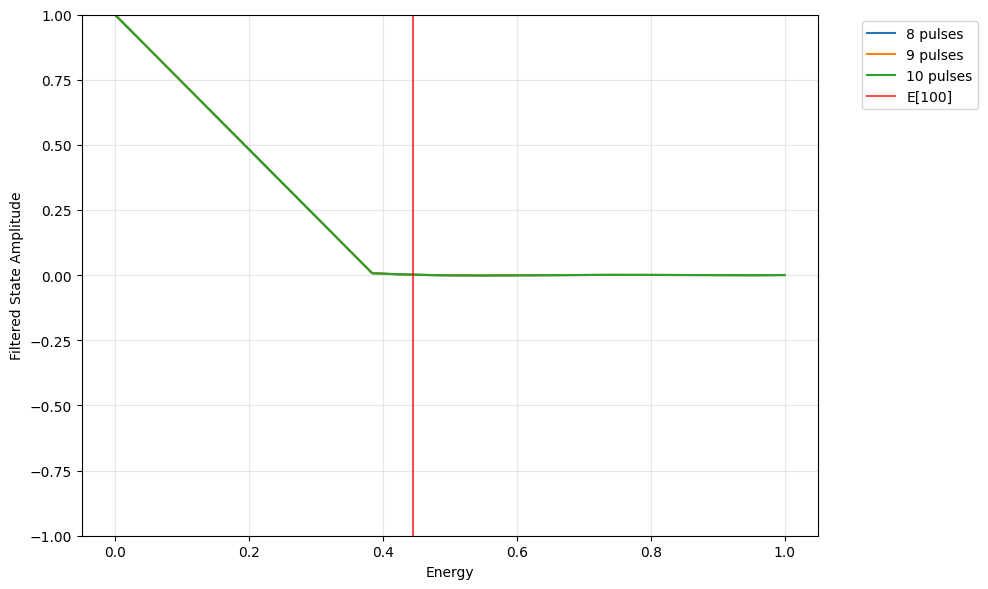

Total time: 0.95 sec


In [3]:
import numpy as np
import time

# === Your physical setup ===
wmin = -3.90983149
wmax = 7.92112829
pre_gap = 0.63219691 - wmin
overlap = 0.34
gap = pre_gap / abs(wmax - wmin)

num_states = int(1e3)
energies = np.zeros(num_states)
energies[1:] = np.linspace(gap, 1, num_states - 1)
totaltime = np.pi / gap

# === Build + Evaluate + Plot in ONE call ===
builder = FilterBuilder(
    total_time=totaltime,
    energies=energies,
    overlap=overlap,
    a=8, b=10
)

start = time.time()
eval_results = builder.build_and_evaluate(
    method="v3",        # or "v3b", "v4"
    highlight_pos=100,
    plot=True
)
print(f"Total time: {time.time() - start:.2f} sec")